In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("car_prices.csv")

In [4]:
df.shape

(558837, 16)

In [7]:
df.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  object 
 2   model         548438 non-null  object 
 3   trim          548186 non-null  object 
 4   body          545642 non-null  object 
 5   transmission  493485 non-null  object 
 6   vin           558833 non-null  object 
 7   state         558837 non-null  object 
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  object 
 11  interior      558088 non-null  object 
 12  seller        558837 non-null  object 
 13  mmr           558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558825 non-null  object 
dtypes: float64(4), int64(1), object(11)
memory usage: 68.2+ MB


In [9]:
df.describe()

,year,condition,odometer,mmr,sellingprice
count,558837.000000,547017.000000,558743.000000,558799.000000,558825.000000
mean,2010.038927,30.672365,68320.017767,13769.377495,13611.358810
std,3.966864,13.402832,53398.542821,9679.967174,9749.501628
min,1982.000000,1.000000,1.000000,25.000000,1.000000
25%,2007.000000,23.000000,28371.000000,7100.000000,6900.000000
50%,2012.000000,35.000000,52254.000000,12250.000000,12100.000000
75%,2013.000000,42.000000,99109.000000,18300.000000,18200.000000
max,2015.000000,49.000000,999999.000000,182000.000000,230000.000000


In [10]:
df.dtypes

year              int64
make             object
model            object
trim             object
body             object
transmission     object
vin              object
state            object
condition       float64
odometer        float64
color            object
interior         object
seller           object
mmr             float64
sellingprice    float64
saledate         object
dtype: object

In [11]:
df.isnull().sum()

year                0
make            10301
model           10399
trim            10651
body            13195
transmission    65352
vin                 4
state               0
condition       11820
odometer           94
color             749
interior          749
seller              0
mmr                38
sellingprice       12
saledate           12
dtype: int64

In [12]:
df.dropna(subset=['vin', 'sellingprice', 'saledate', 'mmr', 'odometer'], inplace=True)

In [13]:
for col in ['make', 'model', 'trim', 'body', 'transmission', 'color', 'interior']:
    df[col].fillna('Unknown', inplace=True)

C:\Users\saksh\AppData\Local\Temp\ipykernel_3100\3402918236.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna('Unknown', inplace=True)


In [14]:
df['condition'].fillna(df['condition'].median(), inplace=True)

C:\Users\saksh\AppData\Local\Temp\ipykernel_3100\698694887.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['condition'].fillna(df['condition'].median(), inplace=True)


In [15]:
print(df.isnull().sum())

year            0
make            0
model           0
trim            0
body            0
transmission    0
vin             0
state           0
condition       0
odometer        0
color           0
interior        0
seller          0
mmr             0
sellingprice    0
saledate        0
dtype: int64


In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df.drop_duplicates(inplace = True)

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df.drop(columns=['vin'], inplace=True)
df.columns.tolist()

['year',
 'make',
 'model',
 'trim',
 'body',
 'transmission',
 'state',
 'condition',
 'odometer',
 'color',
 'interior',
 'seller',
 'mmr',
 'sellingprice',
 'saledate']

In [22]:
df['saledate'] = pd.to_datetime(df['saledate'], errors='coerce')

In [23]:
df['sale_year']  = df['saledate'].dt.year
df['sale_month'] = df['saledate'].dt.month

In [24]:
df.drop(columns=['saledate'], inplace=True)

In [25]:
df['year'] = df['year'].astype(int)
df['odometer'] = df['odometer'].astype(int)

In [26]:
str_cols = ['make', 'model', 'trim', 'body', 'transmission', 'color', 'interior', 'state', 'seller']
for col in str_cols:
    df[col] = df[col].str.strip().str.lower()
df.dtypes

year              int64
make             object
model            object
trim             object
body             object
transmission     object
state            object
condition       float64
odometer          int64
color            object
interior         object
seller           object
mmr             float64
sellingprice    float64
sale_year       float64
sale_month      float64
dtype: object

In [31]:
for col in ['transmission', 'color', 'body']:
    print(df[col].value_counts())

transmission
automatic    475848
unknown       65320
manual        17537
Name: count, dtype: int64
color
black        110957
white        106652
silver        83374
gray          82845
blue          51129
red           43562
—             24685
green         11378
gold          11337
beige          9215
burgundy       8970
brown          6715
orange         2077
purple         1561
off-white      1449
yellow         1285
unknown         742
charcoal        479
turquoise       236
pink             42
lime             15
Name: count, dtype: int64
body
sedan                      241299
suv                        143826
hatchback                   26234
minivan                     25521
coupe                       17749
crew cab                    16392
wagon                       16123
unknown                     13186
convertible                 10475
supercrew                    9032
g sedan                      7417
supercab                     5309
regular cab                  4846
va

In [33]:
df['transmission'] = df['transmission'].replace({
    'auto': 'automatic',
    'man' : 'manual',
    'manu': 'manual'
})
df['color'] = df['color'].replace({'—': 'unknown', 'null': 'unknown'})
for col in ['make', 'model', 'body', 'transmission', 'color', 'interior', 'state']:
    df[col] = df[col].str.strip().str.lower()


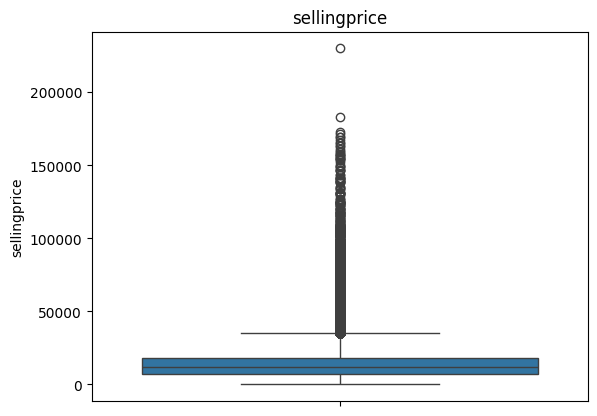

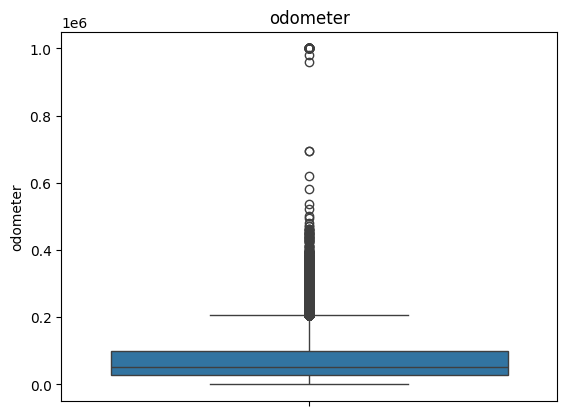

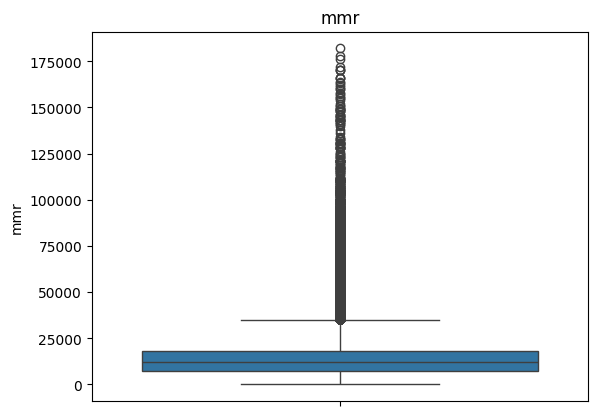

In [34]:
for col in ['sellingprice', 'odometer', 'mmr']:
    sns.boxplot(y=df[col])
    plt.title(col)
    plt.show()

In [35]:
for col in ['sellingprice', 'odometer', 'mmr']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df = df[(df[col] >= Q1 - 1.5 * IQR) & (df[col] <= Q3 + 1.5 * IQR)]

print("Shape after outlier removal:", df.shape)

Shape after outlier removal: (528322, 16)


In [36]:
df = df[df['sellingprice'].between(500, 150000)]
df = df[df['odometer'].between(0, 350000)]
df = df[df['year'].between(1990, 2016)]

In [37]:
df['car_age'] = df['sale_year'] - df['year']
df['price_vs_mmr'] = df['sellingprice'] - df['mmr']
df['price_ratio']  = df['sellingprice'] / df['mmr']

In [38]:
print("==== FINAL DATASET SUMMARY ====")
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())
print("\nData types:\n", df.dtypes)
print("\nNumerical stats:\n", df.describe())

# Save cleaned dataset
df.to_csv('car_prices_cleaned.csv', index=False)
print("\nCleaned file saved!")

==== FINAL DATASET SUMMARY ====
Shape: (524202, 19)

Missing values:
 year                 0
make                 0
model                0
trim                 0
body                 0
transmission         0
state                0
condition            0
odometer             0
color                0
interior             0
seller               0
mmr                  0
sellingprice         0
sale_year       152421
sale_month      152421
car_age         152421
price_vs_mmr         0
price_ratio          0
dtype: int64

Duplicates: 0

Data types:
 year              int64
make             object
model            object
trim             object
body             object
transmission     object
state            object
condition       float64
odometer          int64
color            object
interior         object
seller           object
mmr             float64
sellingprice    float64
sale_year       float64
sale_month      float64
car_age         float64
price_vs_mmr    float64
price_ratio     flo